# n-Armed Bandit

## Preliminaries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from typing import Dict, List, Union, Callable, Tuple, Any
from importlib import reload

## Define a stochastic selector

In [2]:
def stochastic_chooser(probs: np.ndarray, n_picks:int, bin_bounds: str = 'ceiling_inclusive'):
    indices = np.arange(0, probs.shape[0])
    cum_probs_ceilings = np.cumsum(probs)
    cum_probs_floors = np.cumsum(np.hstack([0.0, probs[:-1]]).astype(float))
    seeds = np.random.rand(n_picks,)
    
    picks = np.nan*np.ones(n_picks,)
    for i, seed in enumerate(seeds):
        if bin_bounds == 'floor_inclusive':
            ceiling_check = np.logical_or((cum_probs_ceilings > seed), (1.0*np.ones_like(cum_probs_ceilings) <= seed))
            floor_check = (cum_probs_floors <= seed)
            select_mask = np.logical_and(ceiling_check, floor_check)
            pick = indices[select_mask]

        if bin_bounds == 'ceiling_inclusive':
            floor_check = np.logical_or((cum_probs_floors < seed), (0.0*np.ones_like(cum_probs_floors) >= seed))
            ceiling_check = (cum_probs_ceilings >= seed)
            select_mask = np.logical_and(ceiling_check, floor_check)
            pick = indices[select_mask]
            
        picks[i] = pick
        
    return picks.astype(int)

In [ ]:
# test stochastic_chooser
probs = np.array([0.50, 0.15, 0.10, 0.25])
n_picks = 10

In [ ]:
#action_indices = stochastic_chooser(probs, n_picks, bin_bounds='floor_inclusive')
action_indices = stochastic_chooser(probs, n_picks, bin_bounds='ceiling_inclusive')
action_indices

### Test script version

In [48]:
import torch
import stochastic_chooser as sc

In [49]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

In [50]:
reload(sc)

<module 'stochastic_chooser' from '/Users/ryaneaton/Documents/Repos/reinforcement-learning-exercises/SuttonBartoChapt2/stochastic_chooser.py'>

In [52]:
picks = sc.stochChooser_pt(probs, n_picks, binBounds='ceilingInclusive', device=device)
type(picks), picks

Converting pVec to torch tensor...
Value of indices: tensor([0, 1, 2, 3], device='mps:0', dtype=torch.int32)
Value of seeds: tensor([0.2225, 0.2981, 0.0559, 0.6685, 0.4801, 0.9128, 0.1877, 0.6748, 0.8775,
        0.3385], device='mps:0')
Value of selMask: tensor([ True, False, False, False], device='mps:0')
Value of pick: tensor([0], device='mps:0', dtype=torch.int32)
Value of selMask: tensor([ True, False, False, False], device='mps:0')
Value of pick: tensor([0], device='mps:0', dtype=torch.int32)
Value of selMask: tensor([ True, False, False, False], device='mps:0')
Value of pick: tensor([0], device='mps:0', dtype=torch.int32)
Value of selMask: tensor([False, False,  True, False], device='mps:0')
Value of pick: tensor([2], device='mps:0', dtype=torch.int32)
Value of selMask: tensor([ True, False, False, False], device='mps:0')
Value of pick: tensor([0], device='mps:0', dtype=torch.int32)
Value of selMask: tensor([False, False, False,  True], device='mps:0')
Value of pick: tensor([3],

(torch.Tensor,
 tensor([0, 0, 0, 2, 0, 3, 0, 2, 3, 0], device='mps:0', dtype=torch.int32))

## Define Probabalistic Reward generator

In [4]:
def stochastic_reward_gen(mean_reward_value: float, standard_dev: float) -> float:
    
    seed = np.random.rand(1)
    # Inverse of the cumulative normal distribution at specified mean and standard_deviation
    reward = stats.norm.ppf(seed, loc=mean_reward_value, scale=standard_dev)
    
    return reward

In [5]:
# Test stochastic_reward_gen()
actual_reward_value = -3.0
standard_dev = 2.25
n_reps = 500
gen_rewards = np.array([
    stochastic_reward_gen(actual_reward_value, standard_dev) for rep in range(0, n_reps)
])
mean_gen_rewards = np.mean(gen_rewards)
stdev_gen_rewards = np.std(gen_rewards)

mean_gen_rewards, stdev_gen_rewards

(-3.09303914982212, 2.250833207619588)

## Define Action-value estimator

In [6]:
def action_value_estimator(reward: float, last_estimate: float, k_step: int) -> float:
    
    if k_step < 1:
        updated_estimate = last_estimate
    else:
        k_step = float(k_step)
        updated_estimate = last_estimate + (1. / (k_step + 1.)) * (reward - last_estimate)
    
    return updated_estimate

In [7]:
def action_value_estimator_alpha(
    reward: float, 
    last_estimate: float,
    k_step: int,
    alpha: Union[float, Callable],
    alpha_params: Tuple[Any]=(1.2,)
) -> float:
    
    if k_step < 1:
        updated_estimate = last_estimate
        
    if isinstance(alpha, float):
        updated_estimate = last_estimate + alpha * (reward - last_estimate)
        
    if isinstance(alpha, Callable):
        updated_estimate = last_estimate + alpha(k_step, *alpha_params) * (reward - last_estimate)
        
    return updated_estimate
        

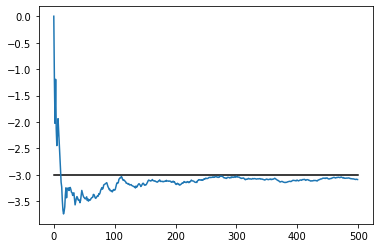

In [9]:
# test action_value_estimator
action_value_estimates = np.nan*np.ones_like(gen_rewards)
action_value_estimates[0] = 0.

for i, gen_reward in enumerate(gen_rewards[:-1]):
    k = i + 1
    action_value_estimates[k] = action_value_estimator(
        gen_reward,
        action_value_estimates[i],
        k
    )

plt.plot(
    [0, action_value_estimates.shape[0]],
    [actual_reward_value, actual_reward_value],
    c="black"
)
plt.plot(action_value_estimates)

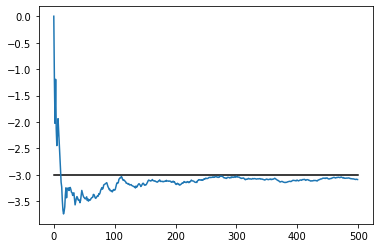

In [14]:
# test action_value_estimator_alpha
action_value_estimates = np.nan*np.ones_like(gen_rewards)
action_value_estimates[0] = 0.

def alpha_k(k_step: int, exponent: float=1.) -> float:
    return (1. / (1 + k_step)) ** exponent

for i, gen_reward in enumerate(gen_rewards[:-1]):
    k = i + 1
    action_value_estimates[k] = action_value_estimator_alpha(
        gen_reward,
        action_value_estimates[i],
        k,
        alpha_k,
        (1.0,)
    )

plt.plot(
    [0, action_value_estimates.shape[0]],
    [actual_reward_value, actual_reward_value],
    c="black"
)
plt.plot(action_value_estimates)



## Define Epsilon Greedy 

In [15]:
def epsilon_greedy_actor(action_value_estimates: np.ndarray, epsilon: float) -> int:
    
    n_actions = action_value_estimates.shape[0]
    action_indices = np.arange(0, n_actions)
    seed = np.random.rand(1)
    if seed < epsilon:
        action_index = np.random.choice(action_indices, size=1, replace=True)
    else:
        action_index = np.argmax(action_value_estimates)
        
    return action_index

In [16]:
# test epsilon_greedy_actor
action_value_estimates = np.array([1., 1., 1., 5., 1., 1.])
epsilon = 0.5
n_runs = 20
selections = np.nan*np.ones(n_runs)
for i in range(0, n_runs):
    selections[i] = epsilon_greedy_actor(action_value_estimates, epsilon)
    
selections.astype(int)

array([3, 3, 3, 5, 5, 3, 2, 4, 3, 3, 3, 0, 4, 3, 3, 4, 5, 3, 3, 4])

## Define Softmax_actor()

In [17]:
def softmax_actor(action_value_estimates: np.ndarray, tau: float) -> int:

    denom = np.sum(np.exp(action_value_estimates / tau))
    numer = np.exp(action_value_estimates / tau)
    
    probs = (1. / denom) * numer
    #print(f"value of probs: {probs}")
    action_index = stochastic_chooser(probs, n_picks=1, bin_bounds='ceiling_inclusive')
    
    return action_index

In [18]:
# test softmax_actor
action_value_estimates = np.array([1., 1., 1., 5., 1., 1.])
tau = 10.
n_runs = 20
selections = np.nan*np.ones(n_runs)
for i in range(0, n_runs):
    selections[i] = softmax_actor(action_value_estimates, tau)
    
selections.astype(int)

array([2, 3, 3, 1, 1, 0, 0, 0, 4, 3, 3, 5, 2, 3, 3, 3, 0, 5, 3, 0])

## Random draw from normal distribution

In [19]:
def draw_random_from_normal(n_actions: int, mean: float, std_dev: float) -> np.ndarray:
    
    seeds = np.random.rand(n_actions)
    drawn_values = np.array([stats.norm.ppf(seed, loc=mean, scale=std_dev) for seed in seeds])
    
    return drawn_values

In [20]:
n_actions = 10
action_values_actual = draw_random_from_normal(n_actions, 0., 1.)
action_values_actual = np.sort(action_values_actual)
action_values_actual

array([-1.16267483, -1.14568108, -0.63685819, -0.49950648, -0.34685878,
       -0.33885939, -0.08885794,  0.67403969,  1.00940105,  2.57806328])

# n-armed bandit

In [77]:
def n_armed_bandit_solve(
    n_arms: int,
    n_runs: int,
    n_steps_per_run: int,
    actor: dict,
    action_value_estimation: Dict[str, Any],
    **kwargs
) -> list:
    
    mean_action_values_init = 0.
    stdev_action_values_init = 1.
    stdev_rewards = 1.
    runs_record = [{}] * n_runs
    new_action_value_estimates = np.random.rand(n_arms)
    
    action_value_estimator = action_value_estimation["function"]
    action_value_estim_params = action_value_estimation["params"]
    
    # Run loop
    for run_i in range(0, n_runs):
        action_record = np.nan*np.ones(n_steps_per_run)
        reward_record = np.nan*np.ones(n_steps_per_run)

        if "non_stationary" in  kwargs.keys():
            action_values_actual = 0.5 * np.ones(n_arms)

            best_actions = np.nan * np.ones(n_steps_per_run)
        else:
            action_values_actual = draw_random_from_normal(
                n_arms,
                mean_action_values_init,
                stdev_action_values_init,
            )
        
            best_actions = np.argmax(action_values_actual) * np.ones(n_steps_per_run)
            # print(f"Best action: {best_action}")
            # print(f"Action values actual: {action_values_actual}")

        #last_action_value_estimates = draw_random_from_normal(n_arms, mean_actuals, stdev_actuals)
        last_action_value_estimates = np.zeros_like(action_values_actual)
        action_select = np.random.choice(np.arange(0, n_arms))
        action_record[0] = action_select
        reward_record[0] = stochastic_reward_gen(
            action_values_actual[action_select],
            stdev_rewards,
        )
        
        # Play loop
        for step_i in range(0, n_steps_per_run - 1):

            step_k = np.sum(action_record == action_select)
            new_action_value_estimates[action_select] = action_value_estimator(
                reward_record[step_i],
                last_action_value_estimates[action_select],
                step_k,
                alpha=action_value_estim_params[0],
                alpha_params=action_value_estim_params[1:]
            )
            
            if actor["function"] == "epsilon-greedy":
                action_select = epsilon_greedy_actor(
                    new_action_value_estimates, *actor["params"]
                )
                
            if  actor["function"] == "softmax_actor":
                action_select = softmax_actor(
                    new_action_value_estimates, *actor["params"]
                )
            
            action_record[step_i + 1] = action_select

            if "non_stationary" in  kwargs.keys():
                # Displace actual action values by random walk iteration
                beta = kwargs["non_stationary"]
                # action_values_actual += beta * (np.random.rand(n_arms) - 0.5)
                # Round to nearest integer in {-1, 0, 1}
                action_values_actual += beta * np.round(2. * (np.random.rand(n_arms) - 0.5))
                # Select element in {-1, 1}
                # seeds = np.random.rand(n_arms)
                # action_values_actual[seeds >= 0.5] += beta 
                # action_values_actual[seeds < 0.5] -= beta
                # action_values_actual[action_values_actual < 0.] = 0.
                # action_values_actual[action_values_actual > 1.] = 1.
                best_actions[step_i + 1] = np.argmax(action_values_actual)
            
            reward_record[step_i + 1] = stochastic_reward_gen(
                action_values_actual[action_select], 
                stdev_rewards
            )

            last_action_value_estimates = new_action_value_estimates

        runs_record[run_i] = dict(
            best_actions=best_actions,
            action_record=action_record.astype(int),
            reward_record=reward_record
        )
        
    return runs_record

In [54]:
# epsilon = 0.
# epsilon = 0.01
epsilon = 0.1

temperature = 1.0
n_arms = 10
n_runs = 500
n_steps_per_run = 1000

mean_actuals = 0.
stdev_actuals = 1.
stdev_rewards = 1.


actor_greedy = dict(
    function="epsilon-greedy",
    params=(epsilon,)
)

actor_softmax = dict(
    function="softmax_actor",
    params=(temperature,)
)

action_value_estimation = {
    "function": action_value_estimator_alpha,
    # "params": (alpha_k, 1.),
    "params": (0.5,)
}
# Step size for non-stationary random walks
# beta = None
beta = 0.25

In [160]:
runs_record = n_armed_bandit_solve(
    n_arms,
    n_runs,
    n_steps_per_run,
    actor=actor_greedy,
    # actor=actor_softmax,
    action_value_estimation=action_value_estimation,
    non_stationary=beta
)

In [109]:
i = 0
runs_record[i]["best_action"], runs_record[i]["action_record"][-10:], runs_record[i]["reward_record"][-10:]

(4,
 array([4, 4, 4, 3, 4, 4, 4, 4, 4, 4]),
 array([ 1.29445693,  1.59599719,  1.16029455, -1.13033461, -0.42654029,
        -0.70112995, -0.53571084,  1.92998105,  1.84298698,  1.07308788]))

## Average runs

In [41]:
def runs_plotter(
    runs_record: List[dict],
    ax_optimal_choice: plt.axes,
    ax_reward: plt.axes,
    color: str="auto",
) -> None:
    
    steps_trace = np.arange(0, runs_record[0]["reward_record"].shape[-1])
    reward_trace = np.zeros_like(runs_record[0]["reward_record"])
    best_trace = np.zeros_like(runs_record[0]["action_record"])
    for i in range(0, n_runs):
        best_actions = runs_record[i]["best_actions"]
        reward_trace += runs_record[i]["reward_record"]
        best_trace += np.equal(runs_record[i]["action_record"], best_actions)

    best_trace = best_trace / n_runs
    reward_trace = reward_trace / n_runs
    
    ax_optimal_choice.plot(steps_trace, best_trace, c=color)
    ax_reward.plot(steps_trace, reward_trace, c=color)
    

## Recreate figure 2.1

In [57]:
# runs_record_ep01 = runs_record
# runs_record_ep00 = runs_record
runs_record_ep1 = runs_record

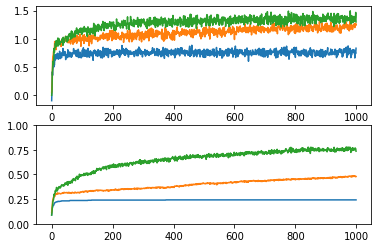

In [74]:
fig, axes = plt.subplots(nrows=2, ncols=1)
axes[1].set_ylim([0., 1.])
# type(axes[0])
#axes[0].plot(reward_trace)
#axes[1].plot(best_trace)

runs_plotter(runs_record_ep00, axes[1], axes[0])
runs_plotter(runs_record_ep01, axes[1], axes[0])
runs_plotter(runs_record_ep1, axes[1], axes[0])


## Exercise 2.7

In [78]:
# Examine performance of n-armed bandit testbed using non-stationary Q*(a) values.  Use 
# an epsilon-greedy actor with epsilon = 0.1. Set up common parameter values across 
# both cases.
n_arms = 10
n_runs = 500
n_steps_per_run = 1000
stdev_rewards = 1.

# Step size for non-stationary random walks
# beta = None
# beta = 0.5
beta = 1.0

epsilon = 0.1
actor_greedy = dict(
    function="epsilon-greedy",
    params=(epsilon,)
)

In [86]:
# Case 1. Use sample averages for action value estimation using alpha = 1/k
def alpha_k(k_step: int, exponent: float=1.) -> float:
    return (1. / (1 + k_step)) ** exponent
# exponent = 1.0
# exponent = 0.8
# exponent = 0.5
exponent = 0.2
action_value_estimation = {
    "function": action_value_estimator_alpha,
    "params": (alpha_k, (exponent,)),
}
runs_record_nonstat_avg_est = n_armed_bandit_solve(
    n_arms,
    n_runs,
    n_steps_per_run,
    actor=actor_greedy,
    action_value_estimation=action_value_estimation,
    non_stationary=beta
)

In [80]:
# Case 2. Use constant step size of alpha = 0.1. Use epsilon = 0.1
action_value_estimation = {
    "function": action_value_estimator_alpha,
    "params": (0.1,)
}

runs_record_nonstat_const_est = n_armed_bandit_solve(
    n_arms,
    n_runs,
    n_steps_per_run,
    actor=actor_greedy,
    action_value_estimation=action_value_estimation,
    non_stationary=beta
)

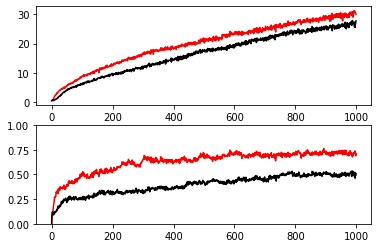

In [87]:
fig_2, axes_2 = plt.subplots(nrows=2, ncols=1)
axes_2[1].set_ylim([0., 1.])

runs_plotter(runs_record_nonstat_avg_est, axes_2[1], axes_2[0], color="red")
runs_plotter(runs_record_nonstat_const_est, axes_2[1], axes_2[0], color="black")


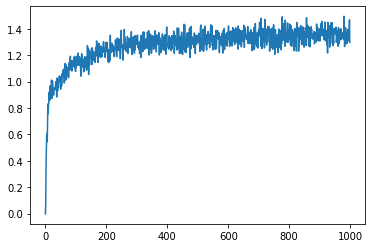